In [1]:
from pathlib import Path
import os

root = Path.cwd().parent
os.chdir(root)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv(r'data\post_feature_engineering_data.csv')

In [4]:
df.head()

,id,qid1,qid2,question1,question2,q1_len,q2_len,q1_words,q2_words,words_unique,...,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,is_duplicate
0,42406,76416,76417,what are the strongest majors in terms of job ...,what are the strongest majors in terms of job ...,107,112,19,20,17,...,1.0,1.0,1.0,19.5,0.850467,98,95,98,100,0
1,350466,479201,479202,how do i apply online for allen asat exam,i am nurture student xth studying i want to...,42,106,9,22,23,...,0.0,0.0,13.0,15.5,0.285714,36,56,31,45,0
2,374273,505161,30183,how do you treat sociopathy and borderline per...,what is borderline personality disorder and h...,65,67,9,11,17,...,0.0,0.0,2.0,10.0,0.492308,57,58,71,78,0
3,190702,289845,188241,how do i write an essay,how should one write an essay on myself,24,40,6,8,11,...,0.0,1.0,2.0,7.0,0.625000,68,78,61,88,1
4,187692,286011,286012,how did you get in shape,what is the fastest way to get in shape for a ...,25,50,6,11,15,...,0.0,0.0,6.0,9.0,0.520000,41,58,41,67,0


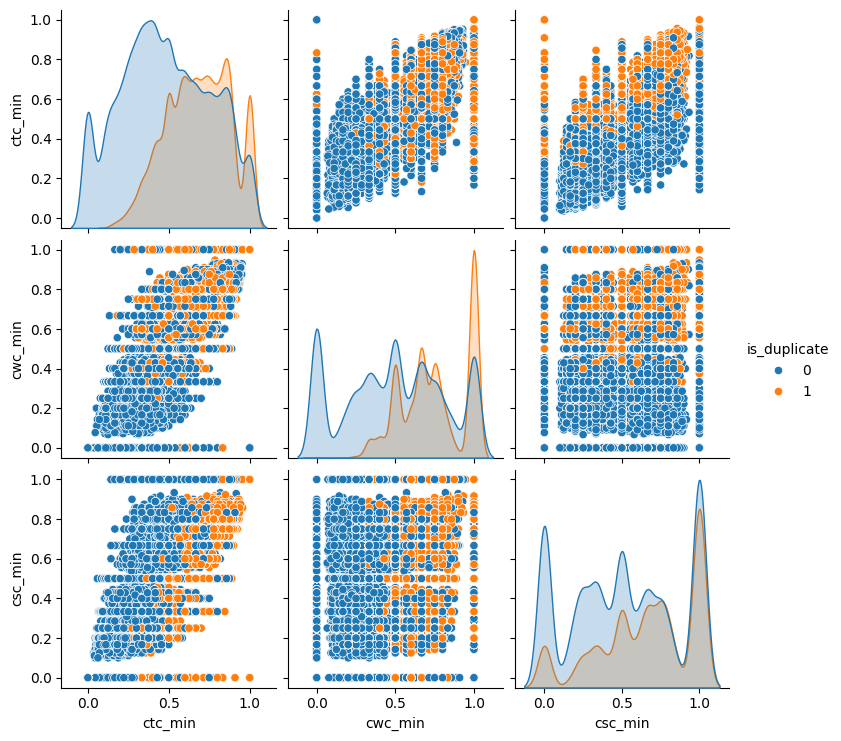

In [5]:
# min related features

sns.pairplot(df[['ctc_min', 'cwc_min', 'csc_min', 'is_duplicate']],hue='is_duplicate')


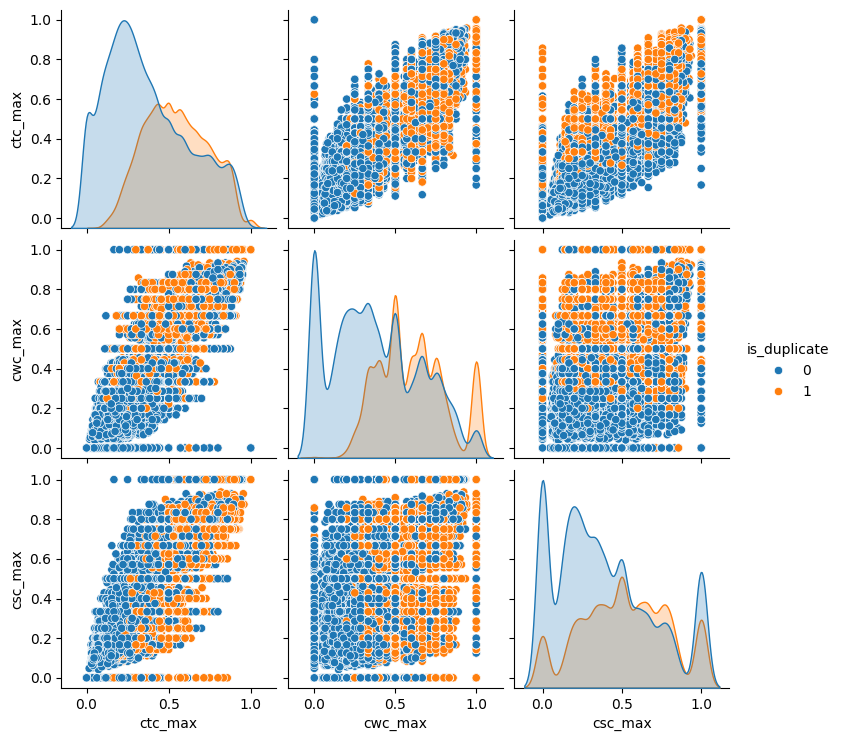

In [6]:
# max related features
sns.pairplot(df[['ctc_max', 'cwc_max', 'csc_max', 'is_duplicate']],hue='is_duplicate')

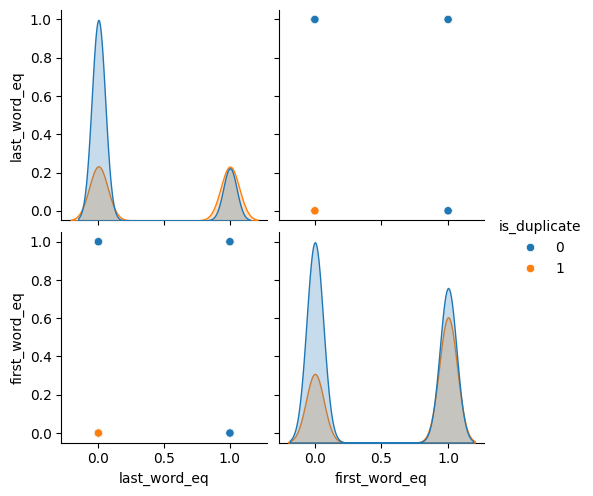

In [7]:
# first word and last word analysis

sns.pairplot(df[['last_word_eq', 'first_word_eq', 'is_duplicate']],hue='is_duplicate')

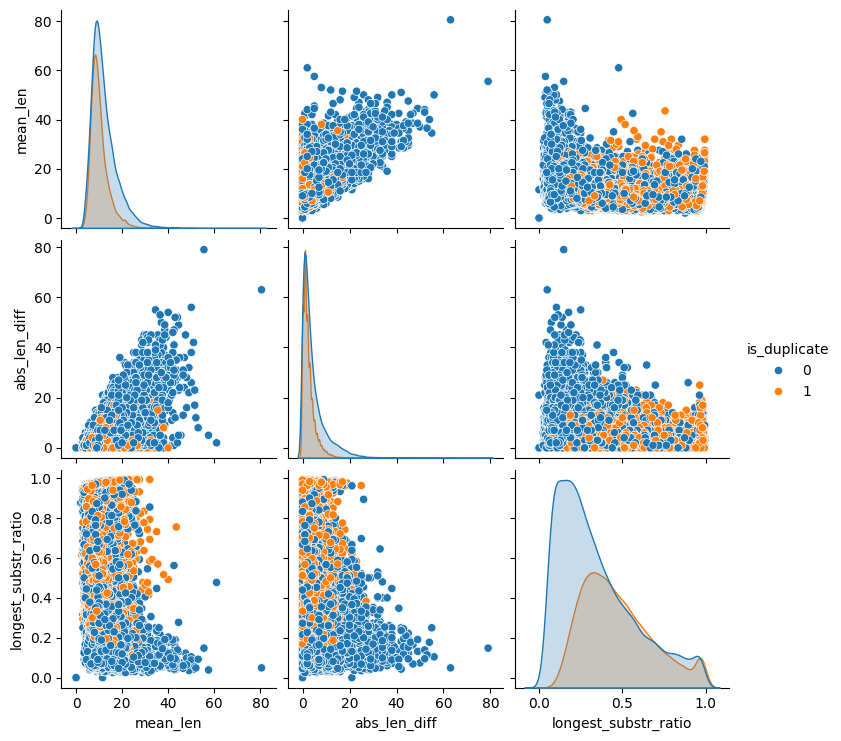

In [8]:
# length features analysis

sns.pairplot(df[['mean_len', 'abs_len_diff','longest_substr_ratio', 'is_duplicate']],hue='is_duplicate')


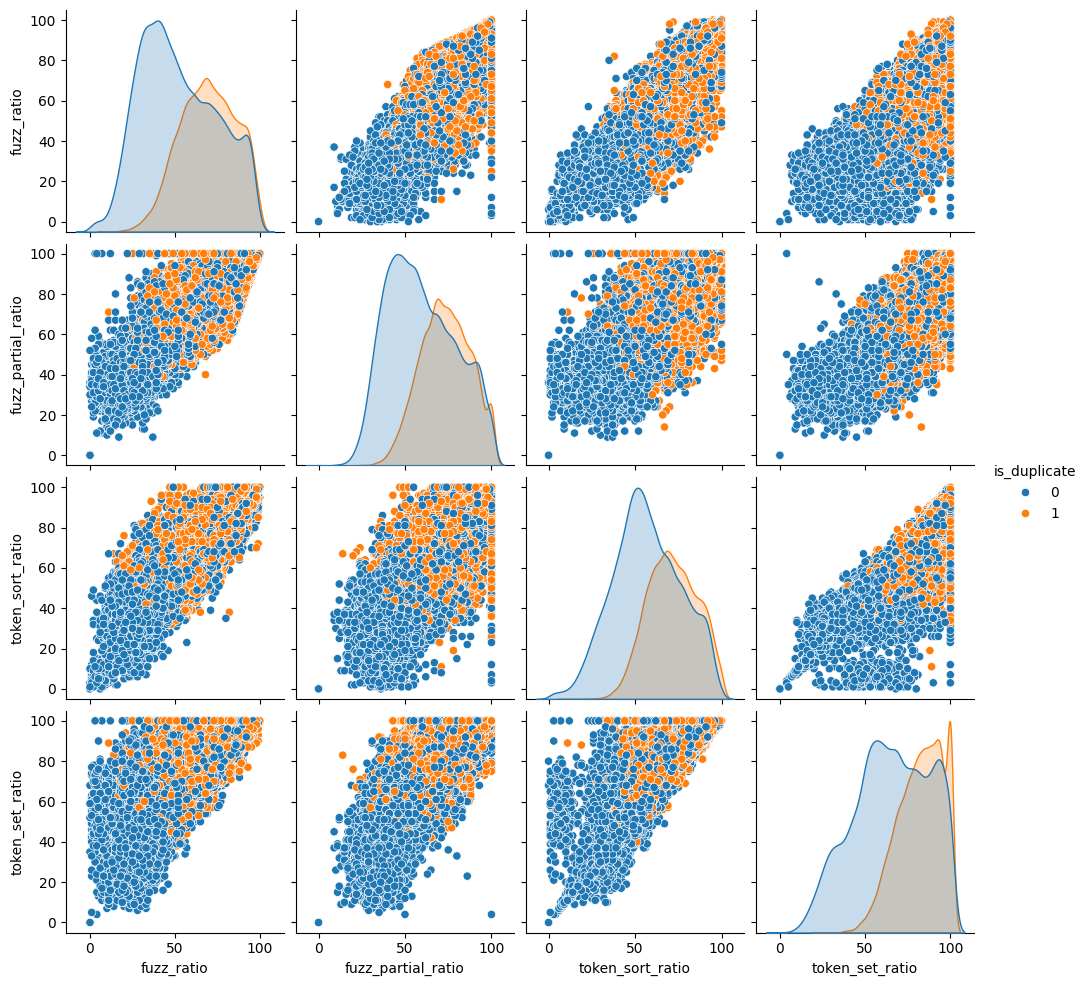

In [9]:
# fuzzy features analysis
sns.pairplot(df[['fuzz_ratio', 'fuzz_partial_ratio','token_sort_ratio','token_set_ratio', 'is_duplicate']],hue='is_duplicate')


### Applying PCA

In [10]:
df.head()

,id,qid1,qid2,question1,question2,q1_len,q2_len,q1_words,q2_words,words_unique,...,last_word_eq,first_word_eq,abs_len_diff,mean_len,longest_substr_ratio,fuzz_ratio,fuzz_partial_ratio,token_sort_ratio,token_set_ratio,is_duplicate
0,42406,76416,76417,what are the strongest majors in terms of job ...,what are the strongest majors in terms of job ...,107,112,19,20,17,...,1.0,1.0,1.0,19.5,0.850467,98,95,98,100,0
1,350466,479201,479202,how do i apply online for allen asat exam,i am nurture student xth studying i want to...,42,106,9,22,23,...,0.0,0.0,13.0,15.5,0.285714,36,56,31,45,0
2,374273,505161,30183,how do you treat sociopathy and borderline per...,what is borderline personality disorder and h...,65,67,9,11,17,...,0.0,0.0,2.0,10.0,0.492308,57,58,71,78,0
3,190702,289845,188241,how do i write an essay,how should one write an essay on myself,24,40,6,8,11,...,0.0,1.0,2.0,7.0,0.625000,68,78,61,88,1
4,187692,286011,286012,how did you get in shape,what is the fastest way to get in shape for a ...,25,50,6,11,15,...,0.0,0.0,6.0,9.0,0.520000,41,58,41,67,0


In [11]:
# min max scaling

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(df[['cwc_min', 'cwc_max', 'csc_min', 'csc_max' , 'ctc_min' , 'ctc_max' , 'last_word_eq', 'first_word_eq' , 'abs_len_diff' , 'mean_len' , 'token_set_ratio' , 'token_sort_ratio' ,  'fuzz_ratio' , 'fuzz_partial_ratio' , 'longest_substr_ratio']])
y = df['is_duplicate'].values



In [12]:
# pca - 2 components

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca.fit_transform(X)

array([[ 1.47838135,  0.30145819],
       [-0.98110004,  0.02449265],
       [-0.43138672,  0.05475111],
       ...,
       [ 0.6933138 , -0.52597927],
       [ 0.77515042, -0.56979086],
       [-0.46324792, -0.73720495]], shape=(50000, 2))

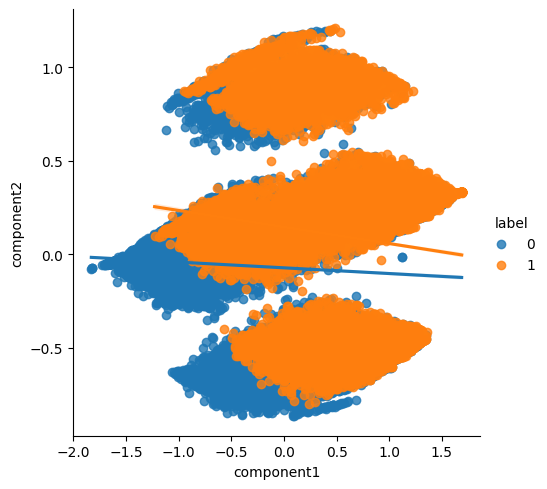

In [13]:
X_df = pd.DataFrame(pca.fit_transform(X), columns = ['component1', 'component2'])
X_df['label'] = y
sns.lmplot(data = X_df, x = 'component1', y = 'component2', hue = 'label')

In [14]:
#pca with 3 components

pca = PCA(n_components=3)
X_df = pd.DataFrame(pca.fit_transform(X), columns = ['component1', 'component2', 'component3'])
X_df['label'] = y

In [15]:
import plotly.express as px

px.scatter_3d(X_df, x = 'component1', y = 'component2', z = 'component3', color = 'label')